# Implementación "Frozen Lake" en Python

Este notebook implementa el entorno Frozen Lake y el algoritmo de Value Iteration desde cero, utilizando únicamente `numpy`, `pandas` y `matplotlib`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Task 2.1 - Modelado del MDP

Implementamos la clase `FrozenLakeMDP` que define los estados, acciones, función de transición $T(s,a,s')$ y función de recompensa $R(s,a,s')$.

In [3]:
class FrozenLakeMDP:
    def __init__(self):
        # Definimos el mapa 4x4 estándar de Frozen Lake
        # S: Start, F: Frozen, H: Hole, G: Goal
        self.desc = np.array([
            ['S', 'F', 'F', 'F'],
            ['F', 'H', 'F', 'H'],
            ['F', 'F', 'F', 'H'],
            ['H', 'F', 'F', 'G']
        ])
        self.nrow, self.ncol = self.desc.shape
        self.n_states = self.nrow * self.ncol # 16 estados (0 a 15)
        self.n_actions = 4 # 4 acciones: 0: Left (W), 1: Down (S), 2: Right (E), 3: Up (N)
        
        # Mapeo de acciones a desplazamientos (fila, columna)
        # N (Up): (-1, 0), S (Down): (1, 0), E (Right): (0, 1), W (Left): (0, -1)
        # Usaremos la convención: 0: W, 1: S, 2: E, 3: N
        self.action_deltas = {
            0: (0, -1), # W (Left)
            1: (1, 0),  # S (Down)
            2: (0, 1),  # E (Right)
            3: (-1, 0)  # N (Up)
        }
        
        # Precomputar el modelo de transiciones T(s, a, s') y recompensas R(s, a, s')
        # P[s][a] será una lista de tuplas (probabilidad, proximo_estado, recompensa, es_terminal)
        self.P = {s: {a: [] for a in range(self.n_actions)} for s in range(self.n_states)}
        self._build_mdp()
        
    def _to_s(self, row, col):
        """Convierte coordenadas (fila, columna) a un índice de estado (0-15)."""
        return row * self.ncol + col
    
    def _inc(self, row, col, a):
        """Calcula la nueva posición intentando moverse en la dirección 'a', limitando a los bordes."""
        delta_r, delta_c = self.action_deltas[a]
        new_row = max(0, min(self.nrow - 1, row + delta_r))
        new_col = max(0, min(self.ncol - 1, col + delta_c))
        return new_row, new_col

    def _build_mdp(self):
        """Construye las funciones de transición T(s,a,s') y recompensa R(s,a,s')."""
        for row in range(self.nrow):
            for col in range(self.ncol):
                s = self._to_s(row, col)
                letter = self.desc[row, col]
                
                # Si es un estado terminal (Agujero o Meta), no hay transiciones a otros estados
                is_terminal = letter in ['G', 'H']
                
                for a in range(self.n_actions):
                    if is_terminal:
                        # T(s, a, s) = 1.0, R = 0 para estados terminales
                        self.P[s][a].append((1.0, s, 0.0, True))
                    else:
                        # Dinámica del hielo resbaladizo:
                        # 1/3 de probabilidad de ir en la dirección deseada
                        # 1/3 de probabilidad de ir en cada dirección perpendicular
                        # Si a=0 (W), perpendiculares son 1 (S) y 3 (N)
                        # Si a=1 (S), perpendiculares son 0 (W) y 2 (E)
                        # Si a=2 (E), perpendiculares son 1 (S) y 3 (N)
                        # Si a=3 (N), perpendiculares son 0 (W) y 2 (E)
                        perpendiculars = [(a - 1) % 4, (a + 1) % 4]
                        intended = [a]
                        
                        transitions = intended + perpendiculars
                        prob = 1.0 / 3.0
                        
                        for trans_a in transitions:
                            new_row, new_col = self._inc(row, col, trans_a)
                            new_s = self._to_s(new_row, new_col)
                            new_letter = self.desc[new_row, new_col]
                            
                            # Función de recompensa R(s, a, s'): +1 si llegamos a 'G', 0 en otro caso
                            reward = 1.0 if new_letter == 'G' else 0.0
                            is_done = new_letter in ['G', 'H']
                            
                            self.P[s][a].append((prob, new_s, reward, is_done))

# Instanciamos el entorno
env = FrozenLakeMDP()
print(f"Estados: {env.n_states}, Acciones: {env.n_actions}")

Estados: 16, Acciones: 4


## Task 2.2 - Algoritmo de Iteración de Valores (Value Iteration)

Implementamos el algoritmo de Value Iteration utilizando la Ecuación de Bellman.

In [4]:
def value_iteration(env, gamma=0.9, epsilon=1e-6):
    """
    Implementa el algoritmo de Value Iteration.
    
    Fórmula de Bellman para Value Iteration:
    V_{k+1}(s) = max_a sum_{s'} T(s,a,s') * [R(s,a,s') + gamma * V_k(s')]
    """
    # 1. Inicialización: Vector de Utilidades V_0(s) = 0 para todos los estados.
    V = np.zeros(env.n_states)
    
    iteration = 0
    while True:
        delta = 0
        V_new = np.zeros(env.n_states)
        
        # 2. Bucle Principal: Para cada estado s
        for s in range(env.n_states):
            # Calculamos el valor esperado para cada acción
            action_values = np.zeros(env.n_actions)
            for a in range(env.n_actions):
                # sum_{s'} T(s,a,s') * [R(s,a,s') + gamma * V_k(s')]
                for prob, next_s, reward, is_terminal in env.P[s][a]:
                    action_values[a] += prob * (reward + gamma * V[next_s])
            
            # V_{k+1}(s) = max_a (Valores esperados de las acciones)
            V_new[s] = np.max(action_values)
            
            # Calculamos la diferencia máxima para verificar convergencia
            delta = max(delta, np.abs(V_new[s] - V[s]))
            
        V = V_new
        iteration += 1
        
        # Itere hasta que la diferencia máxima sea menor a un epsilon pequeño
        if delta < epsilon:
            break
            
    print(f"Value Iteration convergió en {iteration} iteraciones.")
    
    # 3. Extracción de Política:
    # pi*(s) = argmax_a sum_{s'} T(s,a,s') * [R(s,a,s') + gamma * V*(s')]
    policy = np.zeros(env.n_states, dtype=int)
    for s in range(env.n_states):
        action_values = np.zeros(env.n_actions)
        for a in range(env.n_actions):
            for prob, next_s, reward, is_terminal in env.P[s][a]:
                action_values[a] += prob * (reward + gamma * V[next_s])
        policy[s] = np.argmax(action_values)
        
    return V, policy

# Ejecutamos Value Iteration con factor de descuento gamma=0.9
V_opt, policy_opt = value_iteration(env, gamma=0.9)

Value Iteration convergió en 78 iteraciones.


## Visualización

Imprimimos la matriz de 4x4 mostrando la Acción Óptima (flecha) para cada celda y el Mapa de Calor de los valores $V(s)$ finales.

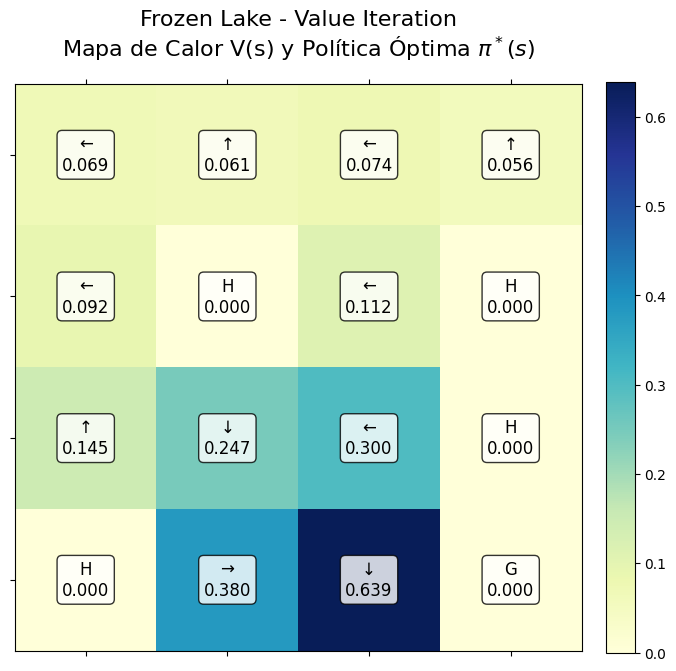

In [5]:
def plot_results(env, V, policy):
    """
    Visualiza el mapa de calor de los valores V(s) y la política óptima.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Reshape de V para que coincida con el grid 4x4
    V_grid = V.reshape((env.nrow, env.ncol))
    
    # 4.b Imprima el Mapa de Calor de los valores V(s) finales
    cax = ax.matshow(V_grid, cmap='YlGnBu')
    fig.colorbar(cax, fraction=0.046, pad=0.04)
    
    # Mapeo de acciones a flechas para la visualización
    # 0: W (Left), 1: S (Down), 2: E (Right), 3: N (Up)
    arrow_map = {0: '←', 1: '↓', 2: '→', 3: '↑'}
    
    for row in range(env.nrow):
        for col in range(env.ncol):
            s = row * env.ncol + col
            letter = env.desc[row, col]
            
            # Texto del valor V(s)
            val_text = f"{V_grid[row, col]:.3f}"
            
            if letter == 'G':
                text = f"G\n{val_text}"
            elif letter == 'H':
                text = f"H\n{val_text}"
            else:
                # 4.a Imprima la matriz de 4x4 mostrando la Acción Óptima (flecha)
                text = f"{arrow_map[policy[s]]}\n{val_text}"
                
            ax.text(col, row, text, va='center', ha='center', color='black', fontsize=12,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
    ax.set_xticks(np.arange(env.ncol))
    ax.set_yticks(np.arange(env.nrow))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(False)
    plt.title("Frozen Lake - Value Iteration\nMapa de Calor V(s) y Política Óptima $\\pi^*(s)$", fontsize=16, pad=20)
    plt.show()

# Visualizamos los resultados
plot_results(env, V_opt, policy_opt)

### Análisis de Resultados

**¿Qué celdas son las más valiosas?**
Como se puede observar en el mapa de calor, las celdas más valiosas (con mayor $V(s)$) son aquellas que están más cerca de la meta (G) en la esquina inferior derecha, específicamente la celda a su izquierda y la celda arriba de ella. El valor disminuye a medida que nos alejamos de la meta debido al factor de descuento $\gamma = 0.9$ y a la probabilidad de caer en un agujero (H) por la estocasticidad del hielo.

Las celdas correspondientes a los agujeros (H) tienen un valor de 0, ya que son estados terminales con recompensa 0. La meta (G) también tiene un valor de 0 en nuestra formulación porque es un estado terminal absorbente (la recompensa se recibe en la transición *hacia* la meta).

**Política Óptima:**
Las flechas indican la acción óptima en cada estado. Notemos que debido a que el hielo es resbaladizo (1/3 de probabilidad de ir en la dirección deseada y 1/3 a cada lado perpendicular), la política óptima a veces parece "contraintuitiva". Por ejemplo, cerca de un agujero, el agente podría elegir apuntar hacia una pared para minimizar la probabilidad de resbalar hacia el agujero, aprovechando que chocar contra la pared lo deja en el mismo estado.